## Hypothesis 1
Increasing the number of training examples will improve the model's ability to generalize to unseen data. With the architecture and all traiing settings held fixed, models trained on larger MNIST dataset can be expected to achive higher validation accuracy and lower validation loss and a smaller difference training and training loss. The hypothesis is that a larger training set contains more variation in handwriting styles, giving the network less opportunity to memorize individual examples and more evidence from which to learn patterns that generalize. I also expect that benefit of adding data to show diminishing returns for example moving from 5K to 10K exmaples may produce a larger imporvement that moving from 25K to 50K. 

In [1]:
from pathlib import Path
import importlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter

import scratch

# Load the newest version of scratch.py.
importlib.reload(scratch)

from scratch import *

In [2]:
print("Loading MNIST data...")

train_dataset, test_dataset = load_mnist_data()

print("Preprocessing MNIST data...")

(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test
) = preprocess_data(
    train_dataset,
    test_dataset,
    train_size=50000,
    test_size=10000,
    SPLIT_SEED=SPLIT_SEED
)

Loading MNIST data...
Preprocessing MNIST data...
Original training images: (60000, 28, 28)
Original training labels: (60000,)
Original test images: (10000, 28, 28)
Original test labels: (10000,)
Splitting the training data into training and validation sets...
Training images: (50000, 28, 28)
Training labels: (50000,)
Validation images: (10000, 28, 28)
Validation labels: (10000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Before Normalization:
Training data range: 0.0 to 255.0
Validation data range: 0.0 to 255.0
Test data range: 0.0 to 255.0
Performing normalization of the data...
After Normalization:
Training data range: 0.0 to 1.0
Validation data range: 0.0 to 1.0
Test data range: 0.0 to 1.0


In [3]:
OH1_OUTPUT_DIR = Path(
    "output/hypotheses/h1_training_size"
)

OH1_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


OH1_TRAINING_SIZES = [
    5000,
    10000,
    25000,
    50000
]

OH1_HIDDEN_SIZE = 128
OH1_ACTIVATION = "relu"
OH1_INITIALIZATION = "small"
OH1_LEARNING_RATE = 0.1
OH1_BATCH_SIZE = 128
OH1_EPOCHS = 100

OH1_SEEDS = generate_experiment_seeds(
    base_seed=SPLIT_SEED,
    number_of_seeds=3
)


print("Original Hypothesis 1")
print("Training sizes:", OH1_TRAINING_SIZES)
print("Hidden size:", OH1_HIDDEN_SIZE)
print("Activation:", OH1_ACTIVATION)
print("Initialization:", OH1_INITIALIZATION)
print("Learning rate:", OH1_LEARNING_RATE)
print("Batch size:", OH1_BATCH_SIZE)
print("Epochs:", OH1_EPOCHS)
print("Seeds:", OH1_SEEDS)
print("Output folder:", OH1_OUTPUT_DIR)

Original Hypothesis 1
Training sizes: [5000, 10000, 25000, 50000]
Hidden size: 128
Activation: relu
Initialization: small
Learning rate: 0.1
Batch size: 128
Epochs: 100
Seeds: [654571, 89250, 773955]
Output folder: output/hypotheses/h1_training_size


In [4]:
oh1_subset_rng = np.random.default_rng(
    SPLIT_SEED
)

oh1_fixed_training_order = (
    oh1_subset_rng.permutation(
        X_train.shape[0]
    )
)


oh1_subset_indices = {}

for training_size in OH1_TRAINING_SIZES:
    oh1_subset_indices[training_size] = (
        oh1_fixed_training_order[
            :training_size
        ]
    )


# Verify the nested relationship.
assert set(
    oh1_subset_indices[5000]
).issubset(
    set(oh1_subset_indices[10000])
)

assert set(
    oh1_subset_indices[10000]
).issubset(
    set(oh1_subset_indices[25000])
)

assert set(
    oh1_subset_indices[25000]
).issubset(
    set(oh1_subset_indices[50000])
)

print("Nested-subset checks passed.")

Nested-subset checks passed.


In [5]:
for training_size in OH1_TRAINING_SIZES:
    print(len(oh1_subset_indices[training_size]))
    print(oh1_subset_indices[training_size])

5000
[  712 24774 45142 ... 43680 18153   951]
10000
[  712 24774 45142 ... 20809 18780 15166]
25000
[  712 24774 45142 ... 36198 49885  7560]
50000
[  712 24774 45142 ...  5668 22113  9864]


In [6]:
# checking class distribution in the subsets
oh1_class_distribution_rows = []


for training_size in OH1_TRAINING_SIZES:

    indices = oh1_subset_indices[
        training_size
    ]

    class_counts = np.bincount(
        y_train[indices],
        minlength=10
    )

    print(
        f"\nTraining size: {training_size:,}"
    )

    print("Class counts:", class_counts)

    for digit, count in enumerate(
        class_counts
    ):
        oh1_class_distribution_rows.append({
            "training_size": training_size,
            "digit": digit,
            "count": int(count),
            "proportion": (
                count / training_size
            )
        })


oh1_class_distribution_df = pd.DataFrame(
    oh1_class_distribution_rows
)

display(
    oh1_class_distribution_df.pivot(
        index="training_size",
        columns="digit",
        values="count"
    )
)
oh1_class_distribution_df.to_csv(
    OH1_OUTPUT_DIR
    / "h1_subset_class_distributions.csv",
    index=False
)


Training size: 5,000
Class counts: [499 581 486 533 506 452 481 500 484 478]

Training size: 10,000
Class counts: [ 999 1117 1009 1026 1016  917  970 1035  940  971]

Training size: 25,000
Class counts: [2504 2829 2446 2590 2449 2266 2473 2610 2404 2429]

Training size: 50,000
Class counts: [4939 5649 4964 5131 4862 4502 4937 5205 4872 4939]


digit,0,1,2,3,4,5,6,7,8,9
training_size,,,,,,,,,,
5000,499,581,486,533,506,452,481,500,484,478
10000,999,1117,1009,1026,1016,917,970,1035,940,971
25000,2504,2829,2446,2590,2449,2266,2473,2610,2404,2429
50000,4939,5649,4964,5131,4862,4502,4937,5205,4872,4939


In [7]:
oh1_results = {}
oh1_final_rows = []
oh1_history_rows = []

total_runs = (
    len(OH1_TRAINING_SIZES)
    * len(OH1_SEEDS)
)

run_number = 0


for training_size in OH1_TRAINING_SIZES:

    print("\n" + "=" * 80)
    print(
        f"Training subset size: "
        f"{training_size:,}"
    )
    print("=" * 80)

    subset_indices = oh1_subset_indices[
        training_size
    ]

    X_train_subset = X_train[
        subset_indices
    ]

    y_train_subset = y_train[
        subset_indices
    ]

    size_histories = []

    for seed in OH1_SEEDS:
        run_number += 1

        print("\n" + "-" * 75)

        print(
            f"Run {run_number}/{total_runs} | "
            f"training size={training_size:,} | "
            f"seed={seed}"
        )

        print("-" * 75)

        checkpoint_filename = (
            f"h1_size_{training_size}_"
            f"seed_{seed}.pt"
        )

        start_time = time.perf_counter()

        parameters, history = train_model(
            X_train=X_train_subset,
            y_train=y_train_subset,
            X_val=X_val,
            y_val=y_val,
            hidden_size=OH1_HIDDEN_SIZE,
            activation=OH1_ACTIVATION,
            initialization=OH1_INITIALIZATION,
            learning_rate=OH1_LEARNING_RATE,
            batch_size=OH1_BATCH_SIZE,
            epochs=OH1_EPOCHS,
            seed=seed,
            verbose=True,
            save_model=True,
            output_dir=OH1_OUTPUT_DIR,
            model_filename=checkpoint_filename
        )

        training_seconds = (
            time.perf_counter()
            - start_time
        )

        # train_model returns the best validation checkpoint
        # when save_model=True.
        selected_train_loss, selected_train_accuracy = (
            evaluate_model(
                X_train_subset,
                y_train_subset,
                parameters,
                OH1_ACTIVATION
            )
        )

        selected_val_loss, selected_val_accuracy = (
            evaluate_model(
                X_val,
                y_val,
                parameters,
                OH1_ACTIVATION
            )
        )

        generalization_gap = (
            selected_train_accuracy
            - selected_val_accuracy
        )

        size_histories.append(history)

        oh1_final_rows.append({
            "training_size": training_size,
            "seed": seed,
            "selected_epoch": history[
                "best_epoch"
            ],
            "train_loss": selected_train_loss,
            "train_accuracy": (
                selected_train_accuracy
            ),
            "validation_loss": (
                selected_val_loss
            ),
            "validation_accuracy": (
                selected_val_accuracy
            ),
            "generalization_gap": (
                generalization_gap
            ),
            "training_seconds": (
                training_seconds
            ),
            "checkpoint_path": history[
                "checkpoint_path"
            ]
        })

        for epoch_index in range(
            len(history["train_loss"])
        ):
            oh1_history_rows.append({
                "training_size": training_size,
                "seed": seed,
                "epoch": epoch_index + 1,
                "train_loss": history[
                    "train_loss"
                ][epoch_index],
                "train_accuracy": history[
                    "train_accuracy"
                ][epoch_index],
                "validation_loss": history[
                    "val_loss"
                ][epoch_index],
                "validation_accuracy": history[
                    "val_accuracy"
                ][epoch_index]
            })

        print(
            f"\nSelected checkpoint | "
            f"epoch={history['best_epoch']} | "
            f"train accuracy="
            f"{100 * selected_train_accuracy:.2f}% | "
            f"validation accuracy="
            f"{100 * selected_val_accuracy:.2f}% | "
            f"generalization gap="
            f"{100 * generalization_gap:.2f} points"
        )

    oh1_results[training_size] = {
        "histories": size_histories
    }


Training subset size: 5,000

---------------------------------------------------------------------------
Run 1/12 | training size=5,000 | seed=654571
---------------------------------------------------------------------------
Epoch 1: Train loss=2.2562, Train accuracy=0.2912, Val loss=2.1384, Val accuracy=0.4824, Best epoch=1
Epoch 10: Train loss=0.3597, Train accuracy=0.8962, Val loss=0.5224, Val accuracy=0.8337, Best epoch=9
Epoch 20: Train loss=0.2559, Train accuracy=0.9258, Val loss=0.3244, Val accuracy=0.9039, Best epoch=20
Epoch 30: Train loss=0.2031, Train accuracy=0.9426, Val loss=0.2859, Val accuracy=0.9136, Best epoch=30
Epoch 40: Train loss=0.1544, Train accuracy=0.9570, Val loss=0.2734, Val accuracy=0.9178, Best epoch=36
Epoch 50: Train loss=0.1193, Train accuracy=0.9698, Val loss=0.2633, Val accuracy=0.9213, Best epoch=49
Epoch 60: Train loss=0.0947, Train accuracy=0.9786, Val loss=0.5278, Val accuracy=0.8509, Best epoch=51
Epoch 70: Train loss=0.0763, Train accuracy=0.98

In [8]:
oh1_final_df = pd.DataFrame(
    oh1_final_rows
)

oh1_history_df = pd.DataFrame(
    oh1_history_rows
)

print("H1 individual results")

display(oh1_final_df)

H1 individual results


,training_size,seed,selected_epoch,train_loss,train_accuracy,validation_loss,validation_accuracy,generalization_gap,training_seconds,checkpoint_path
0,5000,654571,97,0.038389,0.99600,0.256053,0.9293,0.06670,8.732057,output/hypotheses/h1_training_size/h1_size_500...
1,5000,89250,81,0.053840,0.99160,0.250463,0.9282,0.06340,10.009464,output/hypotheses/h1_training_size/h1_size_500...
2,5000,773955,99,0.036234,0.99640,0.251914,0.9285,0.06790,9.515973,output/hypotheses/h1_training_size/h1_size_500...
3,10000,654571,99,0.021372,0.99890,0.166092,0.9536,0.04530,12.481002,output/hypotheses/h1_training_size/h1_size_100...
4,10000,89250,95,0.022750,0.99800,0.162469,0.9540,0.04400,9.228733,output/hypotheses/h1_training_size/h1_size_100...
5,10000,773955,100,0.019600,0.99900,0.162485,0.9547,0.04430,9.330687,output/hypotheses/h1_training_size/h1_size_100...
6,25000,654571,98,0.008625,0.99972,0.103382,0.9722,0.02752,14.905592,output/hypotheses/h1_training_size/h1_size_250...
7,25000,89250,100,0.008408,0.99980,0.107759,0.9709,0.02890,17.906828,output/hypotheses/h1_training_size/h1_size_250...
8,25000,773955,99,0.009110,0.99972,0.104330,0.9725,0.02722,18.504869,output/hypotheses/h1_training_size/h1_size_250...
9,50000,654571,92,0.006031,0.99980,0.075467,0.9797,0.02010,31.826723,output/hypotheses/h1_training_size/h1_size_500...


In [9]:
oh1_final_display_df = pd.DataFrame({
    "Training Size": oh1_final_df[
        "training_size"
    ].map(
        lambda value: f"{value:,}"
    ),
    "Seed": oh1_final_df["seed"],
    "Selected Epoch": oh1_final_df[
        "selected_epoch"
    ],
    "Train Accuracy": oh1_final_df[
        "train_accuracy"
    ].map(
        lambda value: f"{100 * value:.2f}%"
    ),
    "Validation Accuracy": oh1_final_df[
        "validation_accuracy"
    ].map(
        lambda value: f"{100 * value:.2f}%"
    ),
    "Validation Loss": oh1_final_df[
        "validation_loss"
    ].map(
        lambda value: f"{value:.4f}"
    ),
    "Generalization Gap": oh1_final_df[
        "generalization_gap"
    ].map(
        lambda value: (
            f"{100 * value:.2f} points"
        )
    )
})

display(oh1_final_display_df)

,Training Size,Seed,Selected Epoch,Train Accuracy,Validation Accuracy,Validation Loss,Generalization Gap
0,"5,000",654571,97,99.60%,92.93%,0.2561,6.67 points
1,"5,000",89250,81,99.16%,92.82%,0.2505,6.34 points
2,"5,000",773955,99,99.64%,92.85%,0.2519,6.79 points
3,"10,000",654571,99,99.89%,95.36%,0.1661,4.53 points
4,"10,000",89250,95,99.80%,95.40%,0.1625,4.40 points
5,"10,000",773955,100,99.90%,95.47%,0.1625,4.43 points
6,"25,000",654571,98,99.97%,97.22%,0.1034,2.75 points
7,"25,000",89250,100,99.98%,97.09%,0.1078,2.89 points
8,"25,000",773955,99,99.97%,97.25%,0.1043,2.72 points
9,"50,000",654571,92,99.98%,97.97%,0.0755,2.01 points


In [10]:
oh1_summary_df = (
    oh1_final_df
    .groupby(
        "training_size",
        as_index=False
    )
    .agg(
        selected_epoch_mean=(
            "selected_epoch",
            "mean"
        ),
        selected_epoch_std=(
            "selected_epoch",
            "std"
        ),
        train_loss_mean=(
            "train_loss",
            "mean"
        ),
        train_loss_std=(
            "train_loss",
            "std"
        ),
        train_accuracy_mean=(
            "train_accuracy",
            "mean"
        ),
        train_accuracy_std=(
            "train_accuracy",
            "std"
        ),
        validation_loss_mean=(
            "validation_loss",
            "mean"
        ),
        validation_loss_std=(
            "validation_loss",
            "std"
        ),
        validation_accuracy_mean=(
            "validation_accuracy",
            "mean"
        ),
        validation_accuracy_std=(
            "validation_accuracy",
            "std"
        ),
        generalization_gap_mean=(
            "generalization_gap",
            "mean"
        ),
        generalization_gap_std=(
            "generalization_gap",
            "std"
        ),
        training_seconds_mean=(
            "training_seconds",
            "mean"
        ),
        training_seconds_std=(
            "training_seconds",
            "std"
        )
    )
    .sort_values("training_size")
)

In [11]:
oh1_summary_display_rows = []


for _, row in oh1_summary_df.iterrows():

    oh1_summary_display_rows.append({
        "Training Size": (
            f"{int(row['training_size']):,}"
        ),
        "Selected Epoch": (
            f"{row['selected_epoch_mean']:.2f} "
            f"± {row['selected_epoch_std']:.2f}"
        ),
        "Train Accuracy": (
            f"{100 * row['train_accuracy_mean']:.2f}% "
            f"± "
            f"{100 * row['train_accuracy_std']:.2f}%"
        ),
        "Validation Accuracy": (
            f"{100 * row['validation_accuracy_mean']:.2f}% "
            f"± "
            f"{100 * row['validation_accuracy_std']:.2f}%"
        ),
        "Validation Loss": (
            f"{row['validation_loss_mean']:.4f} "
            f"± {row['validation_loss_std']:.4f}"
        ),
        "Generalization Gap": (
            f"{100 * row['generalization_gap_mean']:.2f} "
            f"± "
            f"{100 * row['generalization_gap_std']:.2f} "
            "points"
        ),
        "Training Time": (
            f"{row['training_seconds_mean']:.1f} "
            f"± {row['training_seconds_std']:.1f} sec"
        )
    })


oh1_summary_display_df = pd.DataFrame(
    oh1_summary_display_rows
)


print(
    "H1 RESULTS: "
    "MEAN ± SAMPLE STANDARD DEVIATION"
)

display(oh1_summary_display_df)

H1 RESULTS: MEAN ± SAMPLE STANDARD DEVIATION


,Training Size,Selected Epoch,Train Accuracy,Validation Accuracy,Validation Loss,Generalization Gap,Training Time
0,"5,000",92.33 ± 9.87,99.47% ± 0.27%,92.87% ± 0.06%,0.2528 ± 0.0029,6.60 ± 0.23 points,9.4 ± 0.6 sec
1,"10,000",98.00 ± 2.65,99.86% ± 0.06%,95.41% ± 0.06%,0.1637 ± 0.0021,4.45 ± 0.07 points,10.3 ± 1.8 sec
2,"25,000",99.00 ± 1.00,99.97% ± 0.00%,97.19% ± 0.09%,0.1052 ± 0.0023,2.79 ± 0.09 points,17.1 ± 1.9 sec
3,"50,000",84.33 ± 12.42,99.96% ± 0.02%,97.92% ± 0.07%,0.0776 ± 0.0019,2.04 ± 0.05 points,34.9 ± 3.6 sec


In [12]:
oh1_epoch_summary_df = (
    oh1_history_df
    .groupby(
        [
            "training_size",
            "epoch"
        ],
        as_index=False
    )
    .agg(
        train_loss_mean=(
            "train_loss",
            "mean"
        ),
        train_loss_std=(
            "train_loss",
            "std"
        ),
        train_accuracy_mean=(
            "train_accuracy",
            "mean"
        ),
        train_accuracy_std=(
            "train_accuracy",
            "std"
        ),
        validation_loss_mean=(
            "validation_loss",
            "mean"
        ),
        validation_loss_std=(
            "validation_loss",
            "std"
        ),
        validation_accuracy_mean=(
            "validation_accuracy",
            "mean"
        ),
        validation_accuracy_std=(
            "validation_accuracy",
            "std"
        )
    )
)

Saved: output/hypotheses/h1_training_size/h1_training_size_validation_curves.png
Saved: output/hypotheses/h1_training_size/h1_training_size_validation_curves.pdf


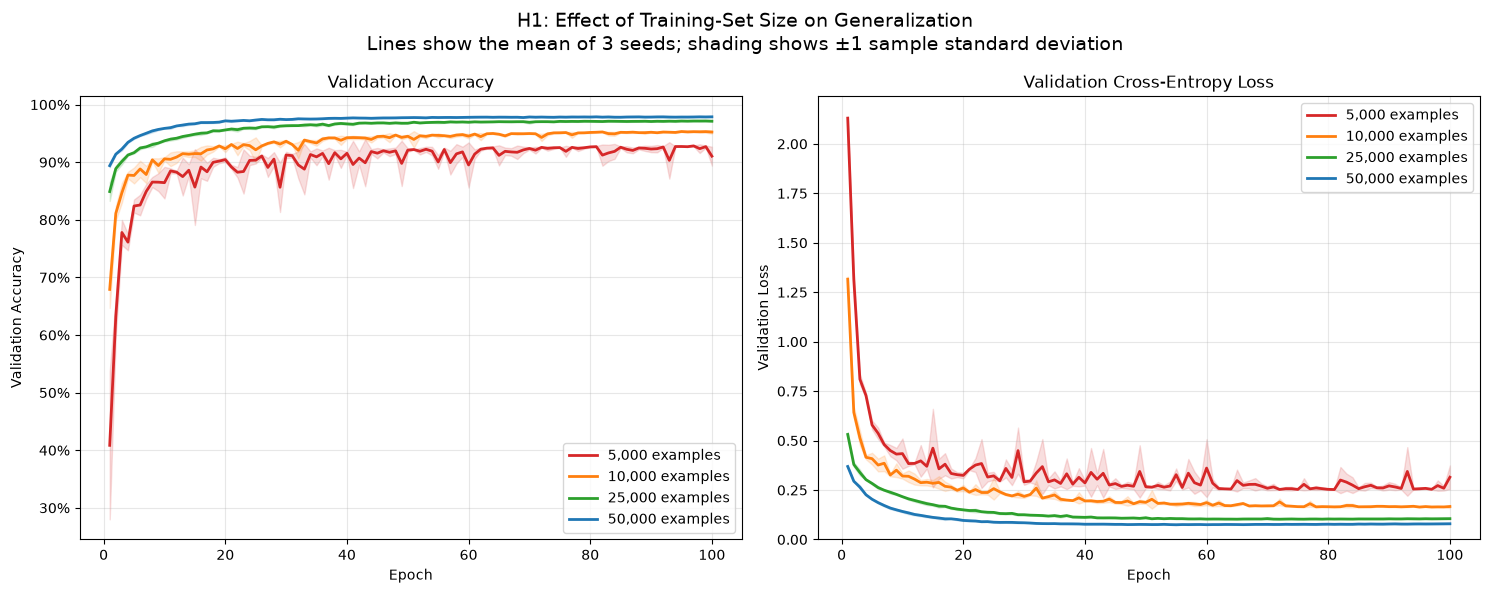

In [13]:
oh1_colors = {
    5000: "tab:red",
    10000: "tab:orange",
    25000: "tab:green",
    50000: "tab:blue"
}


fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)


for training_size in OH1_TRAINING_SIZES:

    size_data = (
        oh1_epoch_summary_df[
            oh1_epoch_summary_df[
                "training_size"
            ] == training_size
        ]
        .sort_values("epoch")
    )

    epochs = size_data[
        "epoch"
    ].to_numpy()

    color = oh1_colors[training_size]

    # Validation accuracy
    accuracy_mean = size_data[
        "validation_accuracy_mean"
    ].to_numpy()

    accuracy_std = size_data[
        "validation_accuracy_std"
    ].to_numpy()

    axes[0].plot(
        epochs,
        accuracy_mean,
        color=color,
        linewidth=2,
        label=f"{training_size:,} examples"
    )

    axes[0].fill_between(
        epochs,
        np.clip(
            accuracy_mean - accuracy_std,
            0,
            1
        ),
        np.clip(
            accuracy_mean + accuracy_std,
            0,
            1
        ),
        color=color,
        alpha=0.15
    )

    # Validation loss
    loss_mean = size_data[
        "validation_loss_mean"
    ].to_numpy()

    loss_std = size_data[
        "validation_loss_std"
    ].to_numpy()

    axes[1].plot(
        epochs,
        loss_mean,
        color=color,
        linewidth=2,
        label=f"{training_size:,} examples"
    )

    axes[1].fill_between(
        epochs,
        np.maximum(
            loss_mean - loss_std,
            0
        ),
        loss_mean + loss_std,
        color=color,
        alpha=0.15
    )


axes[0].set_title(
    "Validation Accuracy"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Accuracy")

axes[0].yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

axes[0].grid(alpha=0.3)
axes[0].legend()


axes[1].set_title(
    "Validation Cross-Entropy Loss"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss")
axes[1].set_ylim(bottom=0)
axes[1].grid(alpha=0.3)
axes[1].legend()


fig.suptitle(
    "H1: Effect of Training-Set Size on Generalization\n"
    "Lines show the mean of 3 seeds; "
    "shading shows ±1 sample standard deviation",
    fontsize=14
)

plt.tight_layout()


oh1_curve_png = (
    OH1_OUTPUT_DIR
    / "h1_training_size_validation_curves.png"
)

oh1_curve_pdf = (
    OH1_OUTPUT_DIR
    / "h1_training_size_validation_curves.pdf"
)


fig.savefig(
    oh1_curve_png,
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    oh1_curve_pdf,
    bbox_inches="tight"
)

print("Saved:", oh1_curve_png)
print("Saved:", oh1_curve_pdf)

plt.show()
plt.close(fig)

Saved: output/hypotheses/h1_training_size/h1_training_size_generalization.png


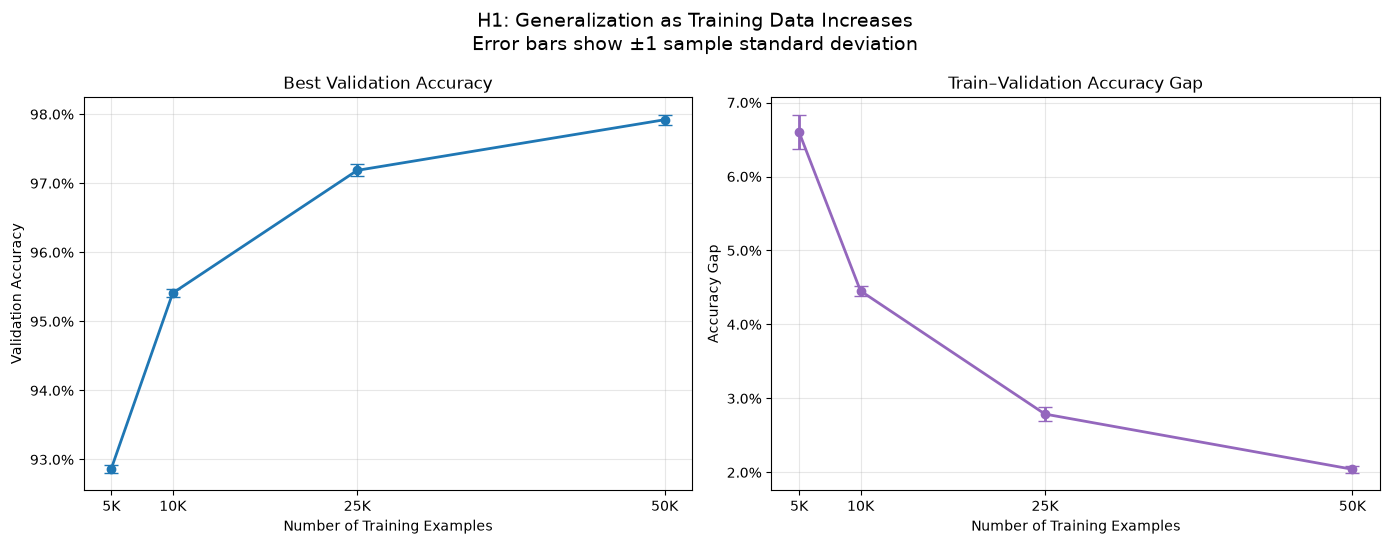

In [14]:
plot_sizes = oh1_summary_df[
    "training_size"
].to_numpy()

validation_accuracy_mean = (
    oh1_summary_df[
        "validation_accuracy_mean"
    ].to_numpy()
)

validation_accuracy_std = (
    oh1_summary_df[
        "validation_accuracy_std"
    ].to_numpy()
)

generalization_gap_mean = (
    oh1_summary_df[
        "generalization_gap_mean"
    ].to_numpy()
)

generalization_gap_std = (
    oh1_summary_df[
        "generalization_gap_std"
    ].to_numpy()
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.5)
)


axes[0].errorbar(
    plot_sizes,
    validation_accuracy_mean,
    yerr=validation_accuracy_std,
    marker="o",
    linewidth=2,
    capsize=5
)

axes[0].set_title(
    "Best Validation Accuracy"
)

axes[0].set_xlabel(
    "Number of Training Examples"
)

axes[0].set_ylabel(
    "Validation Accuracy"
)

axes[0].yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

axes[0].set_xticks(plot_sizes)
axes[0].set_xticklabels([
    f"{size // 1000}K"
    for size in plot_sizes
])

axes[0].grid(alpha=0.3)


axes[1].errorbar(
    plot_sizes,
    generalization_gap_mean,
    yerr=generalization_gap_std,
    marker="o",
    linewidth=2,
    capsize=5,
    color="tab:purple"
)

axes[1].set_title(
    "Train–Validation Accuracy Gap"
)

axes[1].set_xlabel(
    "Number of Training Examples"
)

axes[1].set_ylabel(
    "Accuracy Gap"
)

axes[1].yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

axes[1].set_xticks(plot_sizes)
axes[1].set_xticklabels([
    f"{size // 1000}K"
    for size in plot_sizes
])

axes[1].grid(alpha=0.3)


fig.suptitle(
    "H1: Generalization as Training Data Increases\n"
    "Error bars show ±1 sample standard deviation",
    fontsize=14
)

plt.tight_layout()


oh1_summary_figure_path = (
    OH1_OUTPUT_DIR
    / "h1_training_size_generalization.png"
)

fig.savefig(
    oh1_summary_figure_path,
    dpi=300,
    bbox_inches="tight"
)

print(
    "Saved:",
    oh1_summary_figure_path
)

plt.show()
plt.close(fig)

In [15]:
oh1_final_df.to_csv(
    OH1_OUTPUT_DIR
    / "h1_results_by_seed.csv",
    index=False
)

oh1_final_display_df.to_csv(
    OH1_OUTPUT_DIR
    / "h1_results_by_seed_formatted.csv",
    index=False
)

oh1_summary_df.to_csv(
    OH1_OUTPUT_DIR
    / "h1_summary_numeric.csv",
    index=False
)

oh1_summary_display_df.to_csv(
    OH1_OUTPUT_DIR
    / "h1_summary_formatted.csv",
    index=False
)

oh1_history_df.to_csv(
    OH1_OUTPUT_DIR
    / "h1_all_training_histories.csv",
    index=False
)

oh1_epoch_summary_df.to_csv(
    OH1_OUTPUT_DIR
    / "h1_epoch_mean_std.csv",
    index=False
)


print("Saved H1 files:")

for saved_file in sorted(
    OH1_OUTPUT_DIR.iterdir()
):
    print("-", saved_file)

Saved H1 files:
- output/hypotheses/h1_training_size/h1_all_training_histories.csv
- output/hypotheses/h1_training_size/h1_epoch_mean_std.csv
- output/hypotheses/h1_training_size/h1_results_by_seed.csv
- output/hypotheses/h1_training_size/h1_results_by_seed_formatted.csv
- output/hypotheses/h1_training_size/h1_size_10000_seed_654571.pt
- output/hypotheses/h1_training_size/h1_size_10000_seed_773955.pt
- output/hypotheses/h1_training_size/h1_size_10000_seed_89250.pt
- output/hypotheses/h1_training_size/h1_size_25000_seed_654571.pt
- output/hypotheses/h1_training_size/h1_size_25000_seed_773955.pt
- output/hypotheses/h1_training_size/h1_size_25000_seed_89250.pt
- output/hypotheses/h1_training_size/h1_size_50000_seed_654571.pt
- output/hypotheses/h1_training_size/h1_size_50000_seed_773955.pt
- output/hypotheses/h1_training_size/h1_size_50000_seed_89250.pt
- output/hypotheses/h1_training_size/h1_size_5000_seed_654571.pt
- output/hypotheses/h1_training_size/h1_size_5000_seed_773955.pt
- outpu

In [16]:
ordered_h1_summary = (
    oh1_summary_df
    .sort_values("training_size")
    .reset_index(drop=True)
)


smallest_result = ordered_h1_summary.iloc[0]
largest_result = ordered_h1_summary.iloc[-1]


validation_accuracy_change = (
    largest_result[
        "validation_accuracy_mean"
    ]
    - smallest_result[
        "validation_accuracy_mean"
    ]
)

validation_loss_change = (
    largest_result[
        "validation_loss_mean"
    ]
    - smallest_result[
        "validation_loss_mean"
    ]
)

gap_change = (
    largest_result[
        "generalization_gap_mean"
    ]
    - smallest_result[
        "generalization_gap_mean"
    ]
)


print(
    "Change from "
    f"{int(smallest_result['training_size']):,} "
    "to "
    f"{int(largest_result['training_size']):,} "
    "training examples"
)

print(
    "Validation accuracy change:",
    f"{100 * validation_accuracy_change:+.2f} "
    "percentage points"
)

print(
    "Validation loss change:",
    f"{validation_loss_change:+.4f}"
)

print(
    "Generalization-gap change:",
    f"{100 * gap_change:+.2f} "
    "percentage points"
)


accuracy_means = ordered_h1_summary[
    "validation_accuracy_mean"
].to_numpy()

loss_means = ordered_h1_summary[
    "validation_loss_mean"
].to_numpy()

gap_means = ordered_h1_summary[
    "generalization_gap_mean"
].to_numpy()


print(
    "\nValidation accuracy increases "
    "monotonically:",
    bool(
        np.all(
            np.diff(accuracy_means) >= 0
        )
    )
)

print(
    "Validation loss decreases "
    "monotonically:",
    bool(
        np.all(
            np.diff(loss_means) <= 0
        )
    )
)

print(
    "Generalization gap decreases "
    "monotonically:",
    bool(
        np.all(
            np.diff(gap_means) <= 0
        )
    )
)

Change from 5,000 to 50,000 training examples
Validation accuracy change: +5.05 percentage points
Validation loss change: -0.1752
Generalization-gap change: -4.56 percentage points

Validation accuracy increases monotonically: True
Validation loss decreases monotonically: True
Generalization gap decreases monotonically: True



Testing models trained with 5,000 examples
Seed=654571 | selected epoch=97 | validation accuracy=92.93% | test accuracy=92.65% | test loss=0.2593
Seed=89250 | selected epoch=81 | validation accuracy=92.82% | test accuracy=92.71% | test loss=0.2550
Seed=773955 | selected epoch=99 | validation accuracy=92.85% | test accuracy=92.83% | test loss=0.2590

Testing models trained with 10,000 examples
Seed=654571 | selected epoch=99 | validation accuracy=95.36% | test accuracy=95.27% | test loss=0.1588
Seed=89250 | selected epoch=95 | validation accuracy=95.40% | test accuracy=95.44% | test loss=0.1575
Seed=773955 | selected epoch=100 | validation accuracy=95.47% | test accuracy=95.47% | test loss=0.1566

Testing models trained with 25,000 examples
Seed=654571 | selected epoch=98 | validation accuracy=97.22% | test accuracy=97.26% | test loss=0.0945
Seed=89250 | selected epoch=100 | validation accuracy=97.09% | test accuracy=97.17% | test loss=0.0974
Seed=773955 | selected epoch=99 | validatio

,Training Size,Seed,Selected Epoch,Validation Accuracy,Test Loss,Test Accuracy
0,"5,000",654571,97,92.93%,0.2593,92.65%
1,"5,000",89250,81,92.82%,0.2550,92.71%
2,"5,000",773955,99,92.85%,0.2590,92.83%
3,"10,000",654571,99,95.36%,0.1588,95.27%
4,"10,000",89250,95,95.40%,0.1575,95.44%
5,"10,000",773955,100,95.47%,0.1566,95.47%
6,"25,000",654571,98,97.22%,0.0945,97.26%
7,"25,000",89250,100,97.09%,0.0974,97.17%
8,"25,000",773955,99,97.25%,0.0970,97.25%
9,"50,000",654571,92,97.97%,0.0717,97.87%



H1 TEST PERFORMANCE: MEAN ± SAMPLE STANDARD DEVIATION


,Training Size,Test Loss,Test Accuracy
0,"5,000",0.2578 ± 0.0024,92.73% ± 0.09%
1,"10,000",0.1576 ± 0.0011,95.39% ± 0.11%
2,"25,000",0.0963 ± 0.0016,97.23% ± 0.05%
3,"50,000",0.0729 ± 0.0011,97.88% ± 0.03%


Saved: output/hypotheses/h1_training_size/h1_training_size_test_accuracy.png
Saved: output/hypotheses/h1_training_size/h1_training_size_test_accuracy.pdf


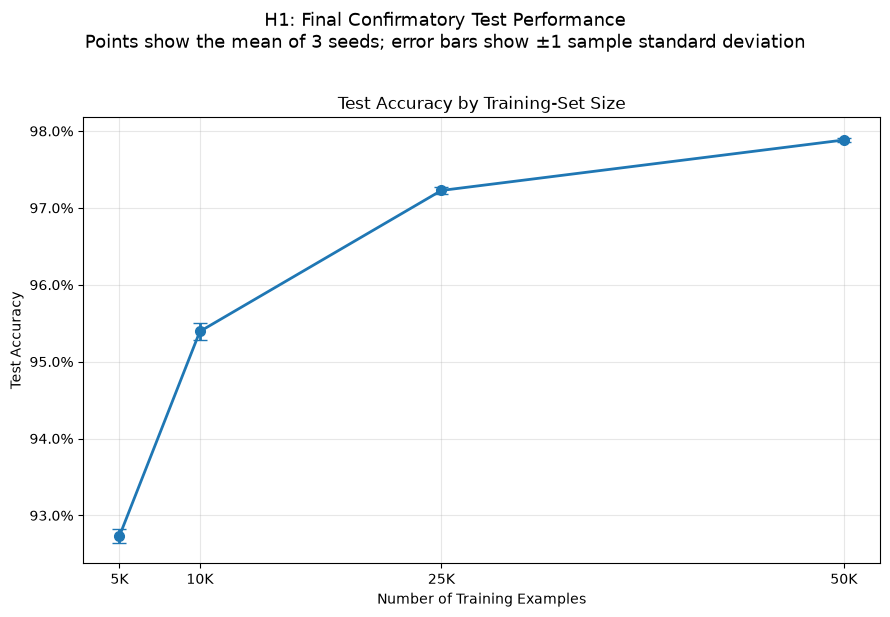


Test change from 5,000 to 50,000 training examples
Test accuracy change: +5.15 percentage points
Test loss change: -0.1848
Test accuracy increases monotonically: True
Test loss decreases monotonically: True


In [18]:


import torch


oh1_test_rows = []


# ------------------------------------------------------------
# 1. Load and test every validation-selected checkpoint
# ------------------------------------------------------------

for training_size in OH1_TRAINING_SIZES:

    print("\n" + "=" * 75)
    print(
        f"Testing models trained with "
        f"{training_size:,} examples"
    )
    print("=" * 75)

    for seed in OH1_SEEDS:

        checkpoint_path = (
            OH1_OUTPUT_DIR
            / (
                f"h1_size_{training_size}_"
                f"seed_{seed}.pt"
            )
        )

        assert checkpoint_path.exists(), (
            f"Checkpoint not found: "
            f"{checkpoint_path}"
        )

        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=True
        )

        # Confirm that this is the expected checkpoint.
        assert checkpoint["seed"] == seed
        assert checkpoint["hidden_size"] == (
            OH1_HIDDEN_SIZE
        )

        assert checkpoint["activation"] == (
            OH1_ACTIVATION
        )

        assert checkpoint["initialization"] == (
            OH1_INITIALIZATION
        )

        assert np.isclose(
            checkpoint["learning_rate"],
            OH1_LEARNING_RATE
        )

        # Convert saved PyTorch tensors back to NumPy arrays.
        loaded_parameters = {
            parameter_name: (
                parameter_tensor
                .cpu()
                .numpy()
                .copy()
            )
            for (
                parameter_name,
                parameter_tensor
            ) in checkpoint[
                "parameters"
            ].items()
        }

        # # Verify parameter shapes.
        # assert loaded_parameters["W1"].shape == (
        #     784,
        #     128
        # )

        # assert loaded_parameters["b1"].shape == (
        #     1,
        #     128
        # )

        # assert loaded_parameters["W2"].shape == (
        #     128,
        #     10
        # )

        # assert loaded_parameters["b2"].shape == (
        #     1,
        #     10
        # )
        

        # Evaluate this checkpoint on the untouched test set.
        test_loss, test_accuracy = evaluate_model(
            X_test,
            y_test,
            loaded_parameters,
            checkpoint["activation"]
        )

        oh1_test_rows.append({
            "training_size": training_size,
            "seed": seed,
            "selected_epoch": checkpoint[
                "best_epoch"
            ],
            "validation_loss": checkpoint[
                "best_val_loss"
            ],
            "validation_accuracy": checkpoint[
                "best_val_accuracy"
            ],
            "test_loss": test_loss,
            "test_accuracy": test_accuracy
        })

        print(
            f"Seed={seed} | "
            f"selected epoch="
            f"{checkpoint['best_epoch']} | "
            f"validation accuracy="
            f"{100 * checkpoint['best_val_accuracy']:.2f}% | "
            f"test accuracy="
            f"{100 * test_accuracy:.2f}% | "
            f"test loss={test_loss:.4f}"
        )


# ------------------------------------------------------------
# 2. Create the individual test-results table
# ------------------------------------------------------------

oh1_test_df = pd.DataFrame(
    oh1_test_rows
)


oh1_test_display_df = pd.DataFrame({
    "Training Size": oh1_test_df[
        "training_size"
    ].map(
        lambda value: f"{value:,}"
    ),
    "Seed": oh1_test_df["seed"],
    "Selected Epoch": oh1_test_df[
        "selected_epoch"
    ],
    "Validation Accuracy": oh1_test_df[
        "validation_accuracy"
    ].map(
        lambda value: f"{100 * value:.2f}%"
    ),
    "Test Loss": oh1_test_df[
        "test_loss"
    ].map(
        lambda value: f"{value:.4f}"
    ),
    "Test Accuracy": oh1_test_df[
        "test_accuracy"
    ].map(
        lambda value: f"{100 * value:.2f}%"
    )
})


print("\nH1 test results for every model")

display(oh1_test_display_df)


# ------------------------------------------------------------
# 3. Calculate test mean ± sample SD
# ------------------------------------------------------------

oh1_test_summary_df = (
    oh1_test_df
    .groupby(
        "training_size",
        as_index=False
    )
    .agg(
        test_loss_mean=(
            "test_loss",
            "mean"
        ),
        test_loss_std=(
            "test_loss",
            "std"
        ),
        test_accuracy_mean=(
            "test_accuracy",
            "mean"
        ),
        test_accuracy_std=(
            "test_accuracy",
            "std"
        )
    )
    .sort_values("training_size")
)


oh1_test_summary_display_rows = []


for _, row in oh1_test_summary_df.iterrows():

    oh1_test_summary_display_rows.append({
        "Training Size": (
            f"{int(row['training_size']):,}"
        ),
        "Test Loss": (
            f"{row['test_loss_mean']:.4f} "
            f"± {row['test_loss_std']:.4f}"
        ),
        "Test Accuracy": (
            f"{100 * row['test_accuracy_mean']:.2f}% "
            f"± "
            f"{100 * row['test_accuracy_std']:.2f}%"
        )
    })


oh1_test_summary_display_df = pd.DataFrame(
    oh1_test_summary_display_rows
)


print(
    "\nH1 TEST PERFORMANCE: "
    "MEAN ± SAMPLE STANDARD DEVIATION"
)

display(oh1_test_summary_display_df)


# ------------------------------------------------------------
# 4. Plot mean test accuracy ±1 SD
# ------------------------------------------------------------

test_plot_sizes = oh1_test_summary_df[
    "training_size"
].to_numpy()

test_accuracy_means = oh1_test_summary_df[
    "test_accuracy_mean"
].to_numpy()

test_accuracy_stds = oh1_test_summary_df[
    "test_accuracy_std"
].to_numpy()


fig, axis = plt.subplots(
    figsize=(9, 6)
)


axis.errorbar(
    test_plot_sizes,
    test_accuracy_means,
    yerr=test_accuracy_stds,
    marker="o",
    markersize=7,
    linewidth=2,
    capsize=5
)


axis.set_title(
    "Test Accuracy by Training-Set Size"
)

axis.set_xlabel(
    "Number of Training Examples"
)

axis.set_ylabel(
    "Test Accuracy"
)

axis.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

axis.set_xticks(
    test_plot_sizes
)

axis.set_xticklabels([
    f"{size // 1000}K"
    for size in test_plot_sizes
])

axis.grid(
    alpha=0.3
)


fig.suptitle(
    "H1: Final Confirmatory Test Performance\n"
    "Points show the mean of 3 seeds; "
    "error bars show ±1 sample standard deviation",
    fontsize=13,
    y=1.02
)

plt.tight_layout()


oh1_test_figure_png = (
    OH1_OUTPUT_DIR
    / "h1_training_size_test_accuracy.png"
)

oh1_test_figure_pdf = (
    OH1_OUTPUT_DIR
    / "h1_training_size_test_accuracy.pdf"
)


fig.savefig(
    oh1_test_figure_png,
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    oh1_test_figure_pdf,
    bbox_inches="tight"
)


print("Saved:", oh1_test_figure_png)
print("Saved:", oh1_test_figure_pdf)

plt.show()
plt.close(fig)


# ------------------------------------------------------------
# 5. Save all test results
# ------------------------------------------------------------

oh1_test_df.to_csv(
    OH1_OUTPUT_DIR
    / "h1_test_results_by_seed.csv",
    index=False
)

oh1_test_display_df.to_csv(
    OH1_OUTPUT_DIR
    / "h1_test_results_by_seed_formatted.csv",
    index=False
)

oh1_test_summary_df.to_csv(
    OH1_OUTPUT_DIR
    / "h1_test_summary_numeric.csv",
    index=False
)

oh1_test_summary_display_df.to_csv(
    OH1_OUTPUT_DIR
    / "h1_test_summary_formatted.csv",
    index=False
)


# ------------------------------------------------------------
# 6. Print the overall test improvement
# ------------------------------------------------------------

smallest_test_result = (
    oh1_test_summary_df.iloc[0]
)

largest_test_result = (
    oh1_test_summary_df.iloc[-1]
)

test_accuracy_improvement = (
    largest_test_result[
        "test_accuracy_mean"
    ]
    - smallest_test_result[
        "test_accuracy_mean"
    ]
)

test_loss_change = (
    largest_test_result[
        "test_loss_mean"
    ]
    - smallest_test_result[
        "test_loss_mean"
    ]
)


print(
    "\nTest change from "
    f"{int(smallest_test_result['training_size']):,} "
    "to "
    f"{int(largest_test_result['training_size']):,} "
    "training examples"
)

print(
    "Test accuracy change:",
    f"{100 * test_accuracy_improvement:+.2f} "
    "percentage points"
)

print(
    "Test loss change:",
    f"{test_loss_change:+.4f}"
)


test_accuracy_is_monotonic = np.all(
    np.diff(test_accuracy_means) >= 0
)

test_loss_is_monotonic = np.all(
    np.diff(
        oh1_test_summary_df[
            "test_loss_mean"
        ].to_numpy()
    ) <= 0
)


print(
    "Test accuracy increases monotonically:",
    bool(test_accuracy_is_monotonic)
)

print(
    "Test loss decreases monotonically:",
    bool(test_loss_is_monotonic)
)